# Assignment 3 – Medical NLP: CXR Radiology Report Classification
### Mansour Arefi
### CM2026 - Advanced Machine Learning for Data-Driven Health

**Task:** Binary classification of chest X-ray radiology reports as *positive* (finding present) or *negative* (no finding).

**Architecture:** BiLSTM (+ Naive Bayes & Logistic Regression benchmarks).

### Structure
1. Setup & Imports
2. Data Loading
3. Label Engineering
4. Exploratory Data Analysis (EDA)
5. Text Preprocessing & Extraction
6. Train / Val / Test Split
7. EDA on Processed Text
8. Vocabulary Building
9. PyTorch Dataset & DataLoader
10. BiLSTM Model
11. Training Loop
12. BiLSTM Evaluation
13. Benchmark Models
14. Comparison Plots
15. Save Model

## 1. Setup & Imports

In [1]:
import re, random, json
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Data Loading

In [2]:
LABELS_FILE = Path("/kaggle/input/datasets/mansourarefi/mimic-cxr-chexpert-labels/mimic-cxr-2.0.0-chexpert.csv")
REPORTS_DIR = Path("/kaggle/input/datasets/mansourarefi/mimic-cxr-reports/mimic-cxr-reports/files")

labels_df = pd.read_csv(LABELS_FILE)
print("Labels shape:", labels_df.shape)
labels_df.head(10)

Labels shape: (227827, 16)


,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
5,10000898,50771383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,10000898,54205396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
7,10000935,50578979,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,-1.0,NaN,1.0,NaN,1.0,NaN,NaN
8,10000935,51178377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,-1.0,NaN,NaN
9,10000935,55697293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


## 3. Label Engineering

CheXpert values: `1.0` = present, `-1.0` = uncertain (dropped), `NaN` = not mentioned.

- **label = 1** (positive): at least one finding column is `1.0` AND `No Finding is not 1.0`
- **label = 0** (negative): `No Finding == 1.0` AND finding columns are `0`

In [3]:
label_cols   = [c for c in labels_df.columns if c not in ("subject_id", "study_id")]
finding_cols = [c for c in label_cols if c != "No Finding"]

labels_df["positive"] = labels_df[finding_cols].eq(1.0).any(axis=1).astype(int)

mask_neg = (labels_df["No Finding"] == 1.0) & (labels_df["positive"] == 0)
mask_pos = (labels_df["positive"]   == 1)   & (labels_df["No Finding"] != 1.0)

df_neg = labels_df[mask_neg].copy(); df_neg["label"] = 0
df_pos = labels_df[mask_pos].copy(); df_pos["label"] = 1

df_all = pd.concat([df_neg, df_pos]).reset_index(drop=True)
print(f"Labeled samples — negative: {(df_all.label==0).sum():,}  positive: {(df_all.label==1).sum():,}")

Labeled samples — negative: 65,282  positive: 141,488


## 4. Exploratory Data Analysis (EDA)

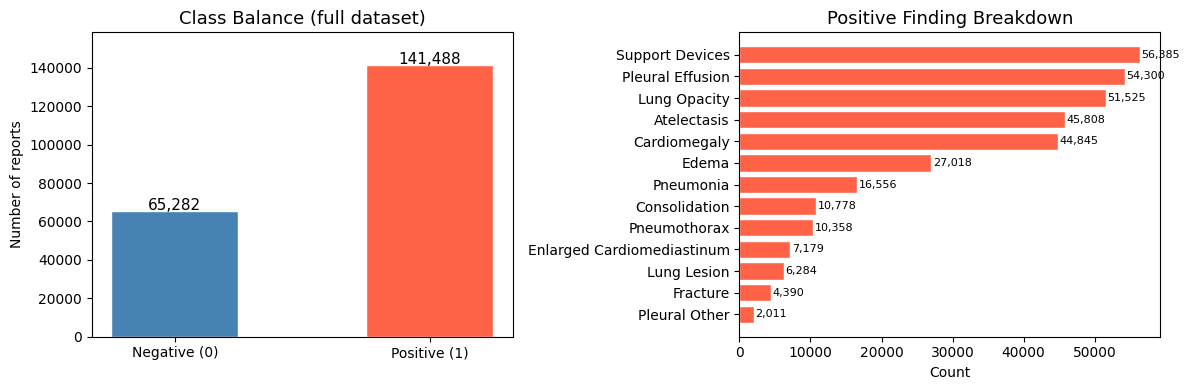


Class ratio (pos/neg): 2.17


In [4]:
#Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
counts = df_all["label"].value_counts().sort_index()
bars = axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,color=["steelblue", "tomato"], edgecolor="white", width=0.5)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}", ha="center", fontsize=11)
    
axes[0].set_title("Class Balance (full dataset)", fontsize=13)
axes[0].set_ylabel("Number of reports")
axes[0].set_ylim(0, counts.max() * 1.12)

# Finding-level breakdown (positive class only)
finding_counts = df_pos[finding_cols].eq(1.0).sum().sort_values(ascending=True)
finding_counts = finding_counts[finding_counts > 0]
axes[1].barh(finding_counts.index, finding_counts.values, color="tomato", edgecolor="white")
axes[1].set_title("Positive Finding Breakdown", fontsize=13)
axes[1].set_xlabel("Count")
for i, v in enumerate(finding_counts.values):
    axes[1].text(v + 200, i, f"{v:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nClass ratio (pos/neg): {(df_all.label==1).sum() / (df_all.label==0).sum():.2f}")

In [5]:
# Print one report of each class
def report_path(subject_id: int, study_id: int) -> Path:
    prefix = f"p{str(subject_id)[:2]}"
    return REPORTS_DIR / prefix / f"p{subject_id}" / f"s{study_id}.txt"

def print_raw_report(label_val, label_name):
    row = df_all[df_all["label"] == label_val].iloc[0]
    p   = report_path(int(row.subject_id), int(row.study_id))
    raw = p.read_text(errors="replace")
    print(f"RAW REPORT — {label_name} (subject {int(row.subject_id)}, study {int(row.study_id)})")
    print(raw)
    print()

print_raw_report(0, "NEGATIVE")
print_raw_report(1, "POSITIVE")

RAW REPORT — NEGATIVE (subject 10000032, study 50414267)
                                 FINAL REPORT
 EXAMINATION:  CHEST (PA AND LAT)
 
 INDICATION:  ___F with new onset ascites  // eval for infection
 
 TECHNIQUE:  Chest PA and lateral
 
 COMPARISON:  None.
 
 FINDINGS: 
 
 There is no focal consolidation, pleural effusion or pneumothorax.  Bilateral
 nodular opacities that most likely represent nipple shadows. The
 cardiomediastinal silhouette is normal.  Clips project over the left lung,
 potentially within the breast. The imaged upper abdomen is unremarkable.
 Chronic deformity of the posterior left sixth and seventh ribs are noted.
 
 IMPRESSION: 
 
 No acute cardiopulmonary process.


RAW REPORT — POSITIVE (subject 10000764, study 57375967)
                                 FINAL REPORT
 EXAMINATION:  CHEST (PA AND LAT)
 
 INDICATION:  ___M with hypoxia  // ?pna, aspiration.
 
 COMPARISON:  None
 
 FINDINGS: 
 
 PA and lateral views of the chest provided.   The lungs are adequa

## 5. Text Preprocessing & Extraction + Data sampling
We combine the **IMPRESSION** and **FINDINGS** sections of each report.
This gives the LSTM both the per-region detail (FINDINGS) and the
summary conclusion (IMPRESSION).

**Preprocessing steps:**
1. Lowercase
2. Remove PHI placeholders (`___`)
3. Remove numbers
4. Remove punctuation
5. Remove `MEDICAL_STOPS` — two layers:
   - Standard English function words (zero discriminative signal)
   - Radiology boilerplate which appear in nearly every report regardless of diagnosis

**Kept:** `no`, `not`, `without`, `clear`, `normal` — these carry the
negation signal that separates negative from positive reports.

In [6]:
def extract_section(text: str, header: str) -> str:
    m = re.search(
        header + r"[:\s]*(.*?)(?=\n\s*[A-Z]{3,}[:\s]|\Z)",
        text, re.DOTALL | re.IGNORECASE
    )
    if m:
        s = m.group(1).strip()
        if len(s) > 5:
            return s
    return ""


# Medical boilerplate that appears in almost every report regardless of finding
# Kept: "no", "not", "without", "clear", "normal" — these carry diagnostic meaning
MEDICAL_STOPS = {
    # Standard English
    "the", "a", "an", "is", "are", "was", "were", "of", "in", "and",
    "to", "with", "has", "have", "been", "be", "on", "at", "for",
    "this", "that", "as", "or", "which", "from", "by", "it", "its",
    "also", "there", "their", "they", "we", "our", "any", "all",
    # Radiology boilerplate (appears in nearly every report)
    "examination", "technique", "indication", "history", "report",
    "chest", "radiograph", "radiographic", "view", "views", "ap",
    "pa", "lateral", "portable", "image", "images", "study",
    "compared", "comparison", "prior", "previous", "again",
    "demonstrate", "demonstrates", "demonstrated", "seen",
    "noted", "note", "identified", "redemonstrated",
    "patient", "year", "old", "female", "male",
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"_{2,}",          " ", text)  # PHI placeholders
    text = re.sub(r"\b\d+\.?\d*\b",  " ", text)  # numbers
    text = re.sub(r"[^a-z\s]",       " ", text)  # punctuation
    tokens = [w for w in text.split() if w not in MEDICAL_STOPS]
    return " ".join(tokens)


def load_report(subject_id: int, study_id: int) -> str:
    p = report_path(subject_id, study_id)
    try:
        raw = p.read_text(errors="replace")
    except FileNotFoundError:
        return ""

    impression = extract_section(raw, "IMPRESSION")
    findings   = extract_section(raw, "FINDINGS")
    combined   = " ".join(x for x in [impression, findings] if x)

    # we use full raw text if both sections empty
    if len(combined.strip()) < 5:
        combined = raw

    result = preprocess(combined)
    # last option: return whatever we have even if short
    return result

## Data Sampling
The negative class is sampled almost completely (65k out of 65,282).
The positive class is downsampled from 141k to 65k. We lose some
positive examples but gain a clean balanced training set.

In [7]:
#Subsample: 65k
N_PER_CLASS = 65000
df_neg_s = df_all[df_all.label == 0].sample(min(N_PER_CLASS, (df_all.label==0).sum()), random_state=SEED)
df_pos_s = df_all[df_all.label == 1].sample(min(N_PER_CLASS, (df_all.label==1).sum()), random_state=SEED)
df = pd.concat([df_neg_s, df_pos_s])[["subject_id", "study_id", "label"]].sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Working set — neg: {(df.label==0).sum():,}  pos: {(df.label==1).sum():,}  total: {len(df):,}")

# Load reports 
print("\nLoading reports (IMPRESSION + FINDINGS) …")
df["text"] = [
    load_report(r.subject_id, r.study_id)
    for _, r in tqdm(df.iterrows(), total=len(df), desc="Reading reports", unit="report")
]

df = df[df["text"].str.len() > 5].reset_index(drop=True)
df["tokens"] = df["text"].str.split()
df = df[df["tokens"].map(len) > 2].reset_index(drop=True)

print(f"\nRows after filtering: {len(df):,}")
print(df["tokens"].map(len).describe().to_string())

Working set — neg: 65,000  pos: 65,000  total: 130,000

Loading reports (IMPRESSION + FINDINGS) …


Reading reports: 100%|██████████| 130000/130000 [14:29<00:00, 149.47report/s]



Rows after filtering: 119,824
count    119824.000000
mean         13.309754
std           9.266649
min           3.000000
25%           8.000000
50%          11.000000
75%          16.000000
max         210.000000


## 6. Train / Val / Test Split (70 / 15 / 15)

In [8]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Train: 83,876  Val: 17,974  Test: 17,974


## 7. EDA on Processed Text

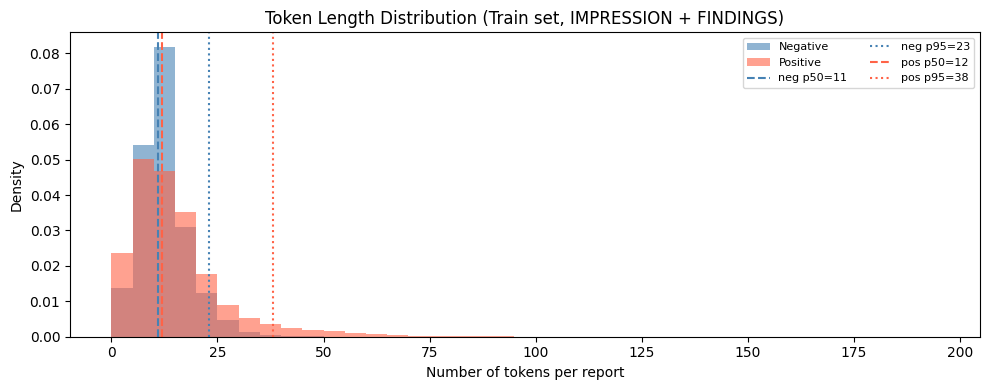


Negative length stats:
count    44400.000000
mean        11.848198
std          5.823300
min          3.000000
25%          8.000000
50%         11.000000
75%         15.000000
max         93.000000

Positive length stats:
count    39476.000000
mean        14.997492
std         11.811538
min          3.000000
25%          8.000000
50%         12.000000
75%         18.000000
max        210.000000


In [9]:
#Tokenlength distributions per class
neg_lens = train_df[train_df.label == 0]["tokens"].map(len)
pos_lens = train_df[train_df.label == 1]["tokens"].map(len)

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, min(int(train_df["tokens"].map(len).max()) + 5, 200), 5)
ax.hist(neg_lens, bins=bins, alpha=0.6, label="Negative", color="steelblue", density=True)
ax.hist(pos_lens, bins=bins, alpha=0.6, label="Positive",  color="tomato",   density=True)

for lens, color, label in [(neg_lens, "steelblue", "neg"), (pos_lens, "tomato", "pos")]:
    for q, ls in [(0.50, "--"), (0.95, ":")] :
        val = int(lens.quantile(q))
        ax.axvline(val, color=color, linestyle=ls, linewidth=1.5,
                   label=f"{label} p{int(q*100)}={val}")

ax.set_xlabel("Number of tokens per report")
ax.set_ylabel("Density")
ax.set_title("Token Length Distribution (Train set, IMPRESSION + FINDINGS)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("/kaggle/working/eda_token_lengths.png", dpi=150)
plt.show()

print("\nNegative length stats:")
print(neg_lens.describe().to_string())
print("\nPositive length stats:")
print(pos_lens.describe().to_string())

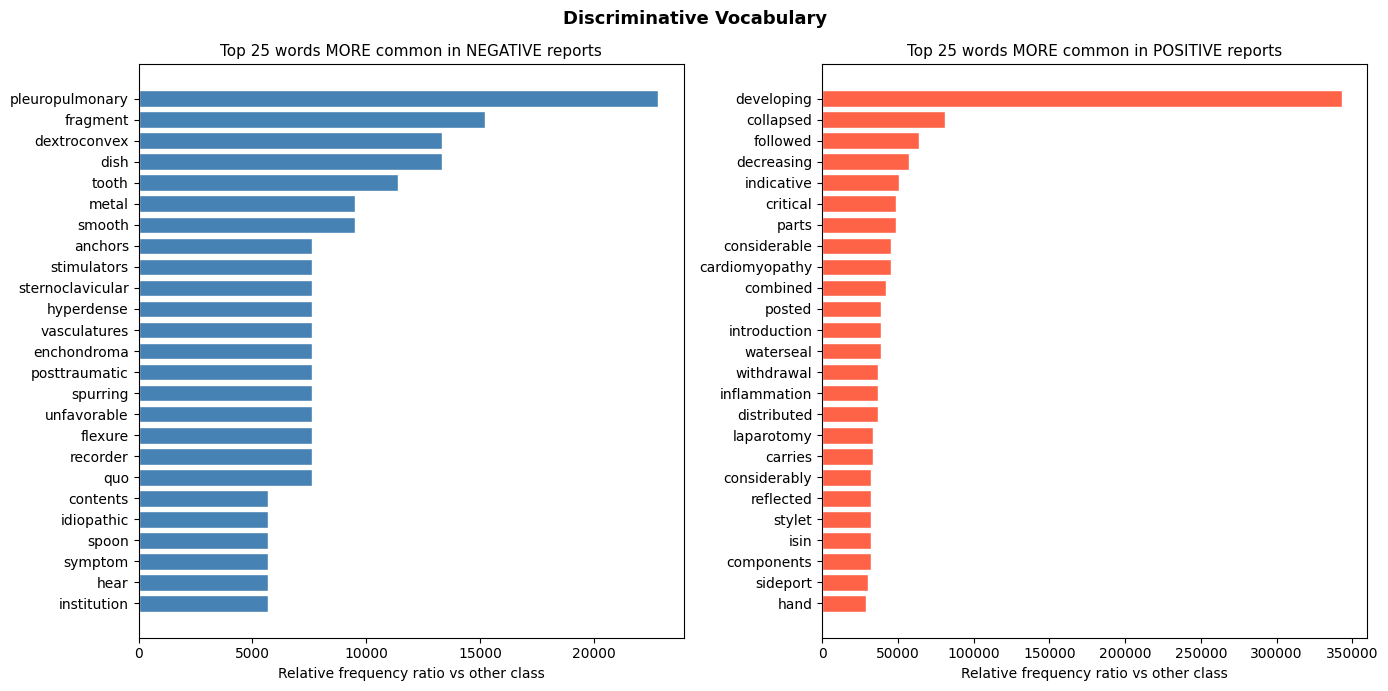

In [10]:
#Top-30 most discriminative words per class
# Count word frequencies separately for each class in train set
neg_words = Counter(tok for tokens in train_df[train_df.label==0]["tokens"] for tok in tokens)
pos_words = Counter(tok for tokens in train_df[train_df.label==1]["tokens"] for tok in tokens)

# Shared stop words to remove (not medically informative)
STOPS = {"the","a","an","is","are","was","were","of","in","and","to","with",
         "no","there","has","have","been","be","on","at","for","this",
         "that","as","or","which","from","not","by","it","its","also",
         "right","left","bilateral","patient","seen","note","noted"}

# Relative frequency ratio: how much more common in class A vs B?
total_neg = sum(neg_words.values()) + 1
total_pos = sum(pos_words.values()) + 1
all_words = set(neg_words) | set(pos_words)

ratio_neg = {w: (neg_words.get(w,0)/total_neg) / (pos_words.get(w,0)/total_pos + 1e-9)
             for w in all_words if w not in STOPS and len(w) > 2}
ratio_pos = {w: (pos_words.get(w,0)/total_pos) / (neg_words.get(w,0)/total_neg + 1e-9)
             for w in all_words if w not in STOPS and len(w) > 2}

top_neg = sorted(ratio_neg, key=ratio_neg.get, reverse=True)[:25]
top_pos = sorted(ratio_pos, key=ratio_pos.get, reverse=True)[:25]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, words, color, title in [
    (axes[0], top_neg, "steelblue", "Top 25 words MORE common in NEGATIVE reports"),
    (axes[1], top_pos, "tomato",    "Top 25 words MORE common in POSITIVE reports"),
]:
    vals = [ratio_neg[w] if color=="steelblue" else ratio_pos[w] for w in words]
    ax.barh(words[::-1], vals[::-1], color=color, edgecolor="white")
    ax.set_xlabel("Relative frequency ratio vs other class")
    ax.set_title(title, fontsize=11)

plt.suptitle("Discriminative Vocabulary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Sample preprocessed reports
print("SAMPLE NEGATIVE REPORT (label=0):")
print(train_df[train_df.label==0].iloc[0]["text"])
print()
print("SAMPLE POSITIVE REPORT (label=1):")
print(train_df[train_df.label==1].iloc[0]["text"])

SAMPLE NEGATIVE REPORT (label=0):
no acute cardiopulmonary process lungs clear focal consolidation pleural effusion pneumothorax

SAMPLE POSITIVE REPORT (label=1):
improving airspace opacities may due resolving edema versus aspiration tracheostomy tube sits level clavicles right ij central


## 8. Vocabulary

In [12]:
MIN_FREQ  = 3
MAX_VOCAB = 30_000

counter = Counter(tok for tokens in train_df["tokens"] for tok in tokens)
vocab_tokens = [tok for tok, cnt in counter.most_common(MAX_VOCAB) if cnt >= MIN_FREQ and tok not in MEDICAL_STOPS ]

PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
vocabulary = {tok: idx for idx, tok in enumerate([PAD_TOKEN, UNK_TOKEN] + vocab_tokens)}
PAD_IDX    = vocabulary[PAD_TOKEN]
UNK_IDX    = vocabulary[UNK_TOKEN]
VOCAB_SIZE = len(vocabulary)

pos_lens_train = train_df[train_df.label == 1]["tokens"].map(len)
MAX_LEN = int(pos_lens_train.quantile(0.95)) 

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"Max sequence len: {MAX_LEN}")
print(f"Top-20 tokens   : {vocab_tokens[:20]}")

Vocabulary size : 3,103
Max sequence len: 38
Top-20 tokens   : ['no', 'acute', 'right', 'cardiopulmonary', 'normal', 'process', 'pleural', 'left', 'lungs', 'effusion', 'lung', 'pneumothorax', 'clear', 'size', 'consolidation', 'heart', 'pulmonary', 'evidence', 'focal', 'contours']


## 9. PyTorch Dataset & DataLoader

In [13]:
class ReportDataset(Dataset):
    def __init__(self, dataframe):
        self.tokens = dataframe["tokens"].tolist()
        self.labels = dataframe["label"].tolist()
        
    def __len__(self):         
        return len(self.labels)
        
    def __getitem__(self, i):  
        return self.tokens[i], self.labels[i]


def collate_fn(batch):
    texts, labels = zip(*batch)
    encoded  = [[vocabulary.get(t, UNK_IDX) for t in toks[:MAX_LEN]] for toks in texts]
    seq_lens = [len(e) for e in encoded]
    max_b    = max(seq_lens)
    padded   = [e + [PAD_IDX] * (max_b - len(e)) for e in encoded]
    return (
        torch.tensor(padded,   dtype=torch.long),
        torch.tensor(labels,   dtype=torch.long),
        torch.tensor(seq_lens, dtype=torch.long),
    )


BATCH_SIZE   = 128  
train_loader = DataLoader(ReportDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(ReportDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(ReportDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches — train: 656  val: 141  test: 141


## 10. BiLSTM Model


In [14]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM text classifier
    Embedding → BiLSTM (num_layers) → Dropout → Linear → logits
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, pad_idx, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        emb            = self.dropout(self.embedding(x))
        packed         = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # hidden: (num_layers*2, batch, hidden_dim)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)   # fwd + bwd last layer
        return self.fc(self.dropout(combined))


EMBED_DIM   = 128
HIDDEN_DIM  = 128
NUM_LAYERS  = 1
DROPOUT     = 0.5
NUM_CLASSES = 2

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, pad_idx=PAD_IDX, dropout=DROPOUT,
).to(DEVICE)

print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BiLSTMClassifier(
  (embedding): Embedding(3103, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

Trainable parameters: 661,890


## 11. Training Loop


In [15]:
LR       = 3e-4
EPOCHS   = 40
PATIENCE = 5
CKPT     = "/kaggle/working/bilstm_best.pt"

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    with torch.set_grad_enabled(train):
        for x, y, lengths in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, lengths)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total


train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float("inf")
no_improve    = 0

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(v_loss)
    new_lr  = optimizer.param_groups[0]["lr"]

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)

    lr_note = f"  ↓ LR→{new_lr:.2e}" if new_lr < prev_lr else ""
    print(f"{epoch:>5}  {t_loss:>10.4f}  {t_acc:>9.4f}  {v_loss:>9.4f}  {v_acc:>8.4f}{lr_note}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss; no_improve = 0
        torch.save(model.state_dict(), CKPT)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

model.load_state_dict(torch.load(CKPT))
print("\nBest model weights restored.")

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
    1      0.2812     0.8887     0.2141    0.9233
    2      0.2114     0.9187     0.1899    0.9340
    3      0.1921     0.9265     0.1747    0.9379
    4      0.1823     0.9300     0.1723    0.9386
    5      0.1770     0.9318     0.1670    0.9409
    6      0.1727     0.9333     0.1647    0.9385
    7      0.1686     0.9347     0.1612    0.9413
    8      0.1657     0.9363     0.1561    0.9422
    9      0.1633     0.9373     0.1556    0.9410
   10      0.1598     0.9383     0.1557    0.9421
   11      0.1556     0.9402     0.1497    0.9438
   12      0.1543     0.9411     0.1493    0.9443
   13      0.1536     0.9407     0.1478    0.9437
   14      0.1497     0.9421     0.1441    0.9469
   15      0.1476     0.9434     0.1445    0.9466
   16      0.1448     0.9442     0.1460    0.9470
   17      0.1437     0.9447     0.1417    0.9478
   18      0.1424     0.9448     0.1413    0

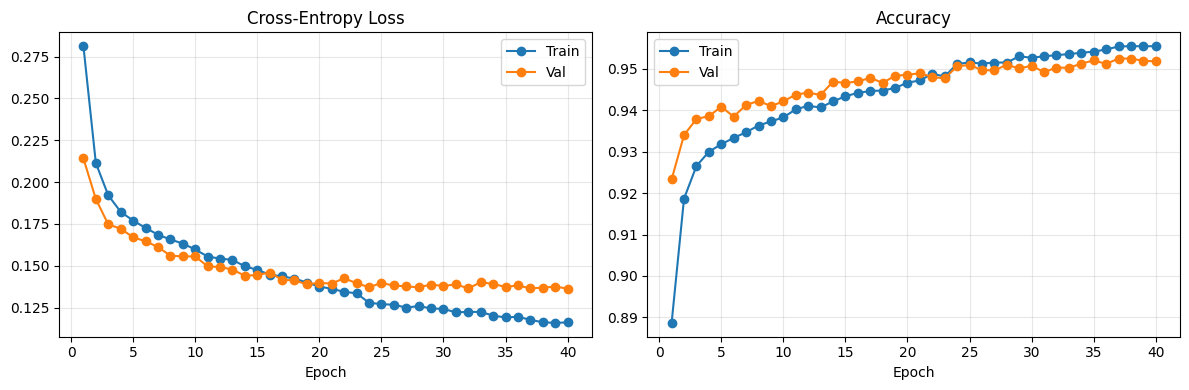

In [16]:
# Training curves
eps  = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(eps, train_losses, marker="o", label="Train")
axes[0].plot(eps, val_losses,   marker="o", label="Val")
axes[0].set_title("Cross-Entropy Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, train_accs, marker="o", label="Train")
axes[1].plot(eps, val_accs,   marker="o", label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

## 12. BiLSTM Evaluation

In [17]:
def evaluate(loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, lengths)
            all_prob.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
            all_pred.extend(logits.argmax(1).cpu().numpy())
            all_true.extend(y.cpu().numpy())
    return np.array(all_true), np.array(all_pred), np.array(all_prob)


y_true_lstm, y_pred_lstm, y_prob_lstm = evaluate(test_loader)

print("BiLSTM – Test Set")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=["Negative", "Positive"]))
print(f"AUC-ROC : {roc_auc_score(y_true_lstm, y_prob_lstm):.4f}")

BiLSTM – Test Set
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95      9515
    Positive       0.95      0.95      0.95      8459

    accuracy                           0.95     17974
   macro avg       0.95      0.95      0.95     17974
weighted avg       0.95      0.95      0.95     17974

AUC-ROC : 0.9895


## 13. Benchmark Models

Two simple linear baselines trained on TF-IDF features:

- **Complement Naive Bayes**: fast, interpretable, strong on text
  classification despite the independence assumption.
- **Logistic Regression**: a linear classifier that can learn
  feature interactions through the TF-IDF weights.

These benchmarks establish the performance floor that the BiLSTM
must meaningfully exceed to justify the added complexity.

In [18]:
tfidf = TfidfVectorizer(max_features=30_000, min_df=3, sublinear_tf=True, stop_words="english")

X_train_tf = tfidf.fit_transform(train_df["text"])
X_test_tf  = tfidf.transform(test_df["text"])
y_train    = train_df["label"].values
y_test     = test_df["label"].values

print("TF-IDF shape:", X_train_tf.shape)

# Complement Naive Bayes
cnb = ComplementNB(alpha=0.1).fit(X_train_tf, y_train)
y_pred_cnb = cnb.predict(X_test_tf)
y_prob_cnb = cnb.predict_proba(X_test_tf)[:, 1]

print("\nComplement Naive Bayes – Test Set")
print(classification_report(y_test, y_pred_cnb, target_names=["Negative", "Positive"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_cnb):.4f}")

# Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=SEED, n_jobs=-1)
lr_clf.fit(X_train_tf, y_train)
y_pred_lr = lr_clf.predict(X_test_tf)
y_prob_lr = lr_clf.predict_proba(X_test_tf)[:, 1]

print("\nLogistic Regression – Test Set")
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

TF-IDF shape: (83876, 2884)

Complement Naive Bayes – Test Set
              precision    recall  f1-score   support

    Negative       0.92      0.86      0.89      9515
    Positive       0.85      0.92      0.88      8459

    accuracy                           0.89     17974
   macro avg       0.89      0.89      0.89     17974
weighted avg       0.89      0.89      0.89     17974

AUC-ROC: 0.9510

Logistic Regression – Test Set
              precision    recall  f1-score   support

    Negative       0.94      0.91      0.92      9515
    Positive       0.90      0.93      0.92      8459

    accuracy                           0.92     17974
   macro avg       0.92      0.92      0.92     17974
weighted avg       0.92      0.92      0.92     17974

AUC-ROC: 0.9734


## 14. Comparison Plots

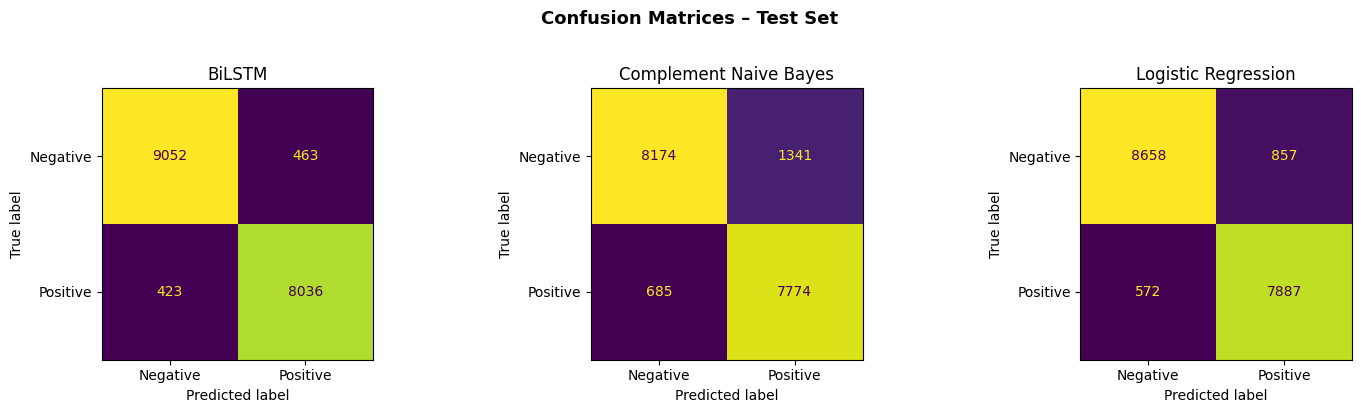

In [19]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = ["Negative", "Positive"]
for ax, y_pred, title in zip(
    axes,
    [y_pred_lstm, y_pred_cnb, y_pred_lr],
    ["BiLSTM", "Complement Naive Bayes", "Logistic Regression"],
):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=names).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("Confusion Matrices – Test Set", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

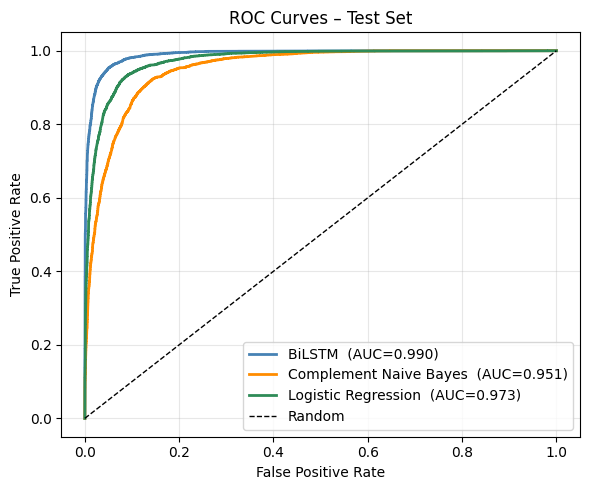

In [20]:
#ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for y_prob, label, color in [
    (y_prob_lstm, "BiLSTM",                "steelblue"),
    (y_prob_cnb,  "Complement Naive Bayes", "darkorange"),
    (y_prob_lr,   "Logistic Regression",    "seagreen"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{label}  (AUC={roc_auc_score(y_test, y_prob):.3f})", lw=2, color=color)
ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – Test Set"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150)
plt.show()

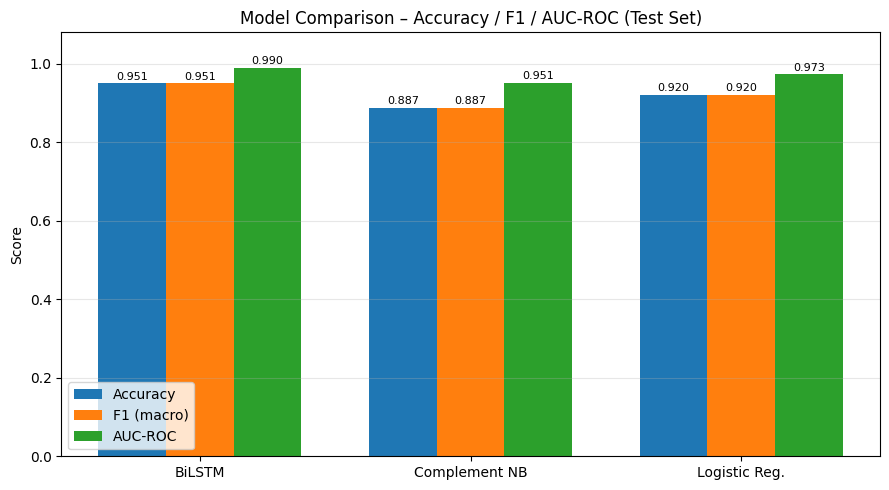

        Model Accuracy F1 (macro) AUC-ROC
       BiLSTM   0.9507     0.9505  0.9895
Complement NB   0.8873     0.8872  0.9510
Logistic Reg.   0.9205     0.9203  0.9734


In [21]:
# Bar chart: all metrics 
model_names = ["BiLSTM", "Complement NB", "Logistic Reg."]
metrics = {
    "Accuracy":  [accuracy_score(y_test, p)            for p in [y_pred_lstm, y_pred_cnb, y_pred_lr]],
    "F1 (macro)":[f1_score(y_test, p, average="macro") for p in [y_pred_lstm, y_pred_cnb, y_pred_lr]],
    "AUC-ROC":   [roc_auc_score(y_test, p)             for p in [y_prob_lstm, y_prob_cnb, y_prob_lr]],
}

x, w = np.arange(len(model_names)), 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i*w, vals, width=w, label=metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.004,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + w); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.08); ax.set_ylabel("Score")
ax.set_title("Model Comparison – Accuracy / F1 / AUC-ROC (Test Set)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison.png", dpi=150)
plt.show()

# Summary table
print(pd.DataFrame({"Model": model_names, **{k: [f"{v:.4f}" for v in vals]
                    for k, vals in metrics.items()}}).to_string(index=False))

## 15. Save Model

In [22]:
torch.save(model.state_dict(), "/kaggle/working/bilstm_final.pt")

with open("/kaggle/working/model_config.json", "w") as f:
    json.dump(dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                   num_layers=NUM_LAYERS, dropout=DROPOUT, num_classes=NUM_CLASSES,
                   pad_idx=PAD_IDX, max_len=MAX_LEN), f, indent=2)

with open("/kaggle/working/vocabulary.json", "w") as f:
    json.dump(vocabulary, f)

print("Saved: bilstm_final.pt  |  model_config.json  |  vocabulary.json")

# Reload snippet
# with open("model_config.json") as f: cfg = json.load(f)
# model_loaded = BiLSTMClassifier(**cfg)
# model_loaded.load_state_dict(torch.load("bilstm_final.pt", map_location="cpu"))
# model_loaded.eval()

Saved: bilstm_final.pt  |  model_config.json  |  vocabulary.json


---
## Summary of Design Choices

| Choice | Initial | Final | Reason |
|--------|---------|-------|--------|
| **Learning rate** | `1e-5` | **`3e-4`** | `1e-5` is fine-tuning territory |
| **Hidden dim** | 256 | **128** | Matched to embed dim. 256 was over-capacity for 13-token sequences and caused early overfitting |
| **Num layers** | 2 | **1** | Second layer added no useful abstraction for short clinical phrases |
| **Dropout** | 0.3 | **0.5** | Higher dropout needed after reducing model capacity |
| **weight_decay** | 0 | **`1e-4`** | Light L2 regularisation alongside higher LR |
| **Data per class** | 65k | 65k | Unchanged — covers almost all negatives, balanced set |
| **Text input** | IMPRESSION only | **IMPRESSION + FINDINGS** | Richer context |
| **Benchmarks** | Complement NB + LR | Same | Clean linear baselines on TF-IDF |